  Activating project at `~/notebooks/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
   Resolving package versions...


============|Starting random seed 1|============
============|Acceleration is 10.0|============
UNIVERSAL
    initializing optimizer...


  No Changes to `~/notebooks/src/Project.toml`
  No Changes to `~/notebooks/src/Manifest.toml`


        applying constraint: timesteps all equal constraint
        applying constraint: initial value of Ũ⃗
        applying constraint: initial value of a
        applying constraint: final value of a
        applying constraint: bounds on a
        applying constraint: bounds on da
        applying constraint: bounds on dda
        applying constraint: bounds on Δt
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    60090
Number of nonzeros in inequality constraint Jacobian.:       32
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     2210
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      442
                     variables with only upper bounds:        0
Total number of equality constraints.................:     2009
Total number of inequality constraints......

Excessive output truncated after 524307 bytes.

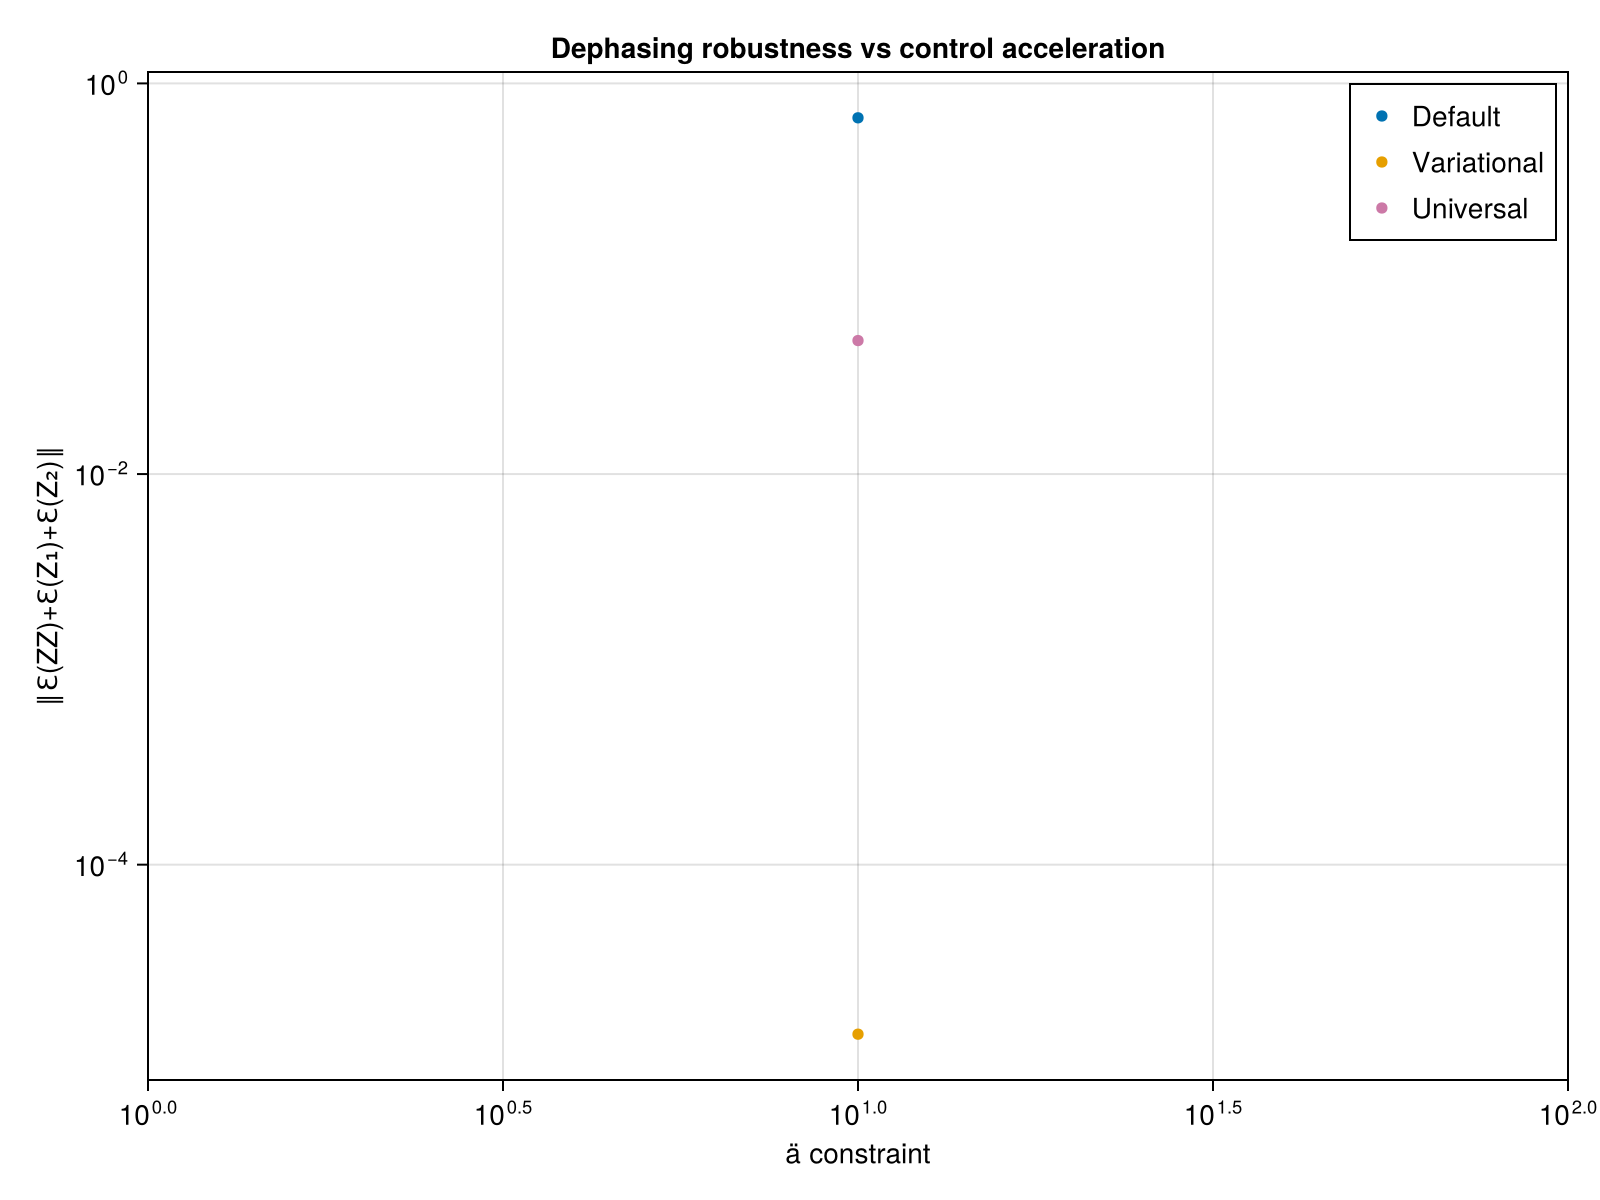

CairoMakie.Screen{IMAGE}


In [7]:
import Pkg; Pkg.activate(".."); Pkg.instantiate();
Pkg.develop(path="../../../QuantumCollocation.jl")
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using SparseArrays
using Statistics
using CairoMakie
using Random
using NamedTrajectories
⊗ = kron;

# variational objective metric
function var_obj(
    traj::NamedTrajectory, 
    H_drift::Matrix{ComplexF64},
    H_drives::Vector{Matrix{ComplexF64}}, 
    H_errors::Vector{Matrix{ComplexF64}}
)
    Δt = traj.Δt[1]
    T = traj.T
    varsys = VariationalQuantumSystem(H_drift, H_drives, H_errors)
    Ũ⃗, ∂Ũ⃗ = variational_unitary_rollout(traj, varsys)

    U = iso_vec_to_operator(Ũ⃗[:, end])
    # First error term
    ∂U = iso_vec_to_operator(∂Ũ⃗[1][:, end])

    d = size(U, 1)
    return abs(tr((U'*∂U)'*(U'*∂U))) / ((T-1) * Δt)^2 / d
end

function scatter_with_line!(ax, x, y; color, label)
    lines!(ax, x, y; color=color, linewidth=2)         # connect points
    scatter!(ax, x, y; color=color, marker=:circle, 
                markersize=8, label=label)                 # overlay dots + legend
end

# Problem parameters
seed = 1
println("============|Starting random seed $seed|============")
var_avg_vec = [] # ZZ, Z1, Z2 average
def_avg_vec = []
uni_avg_vec = []

var_full_vec = []
def_full_vec = []
uni_full_vec = []

var_F = []
def_F = []
uni_F = []

#ä_vals = exp10.(range(-2, stop = 3, length = 10))
ä = 10.0
ä_vals = [ä]
F = 0.9999 # target fidelity
T = 50
Δt = 0.2
num_iter = 1000
iSWAP = exp(1.0im * π / 4 * (PAULIS.X ⊗ PAULIS.X + PAULIS.Y ⊗ PAULIS.Y))
U_goal = iSWAP
a_bound = 5.0
println("============|Acceleration is $ä|============")

X1 = GATES.X ⊗ GATES.I
Y1 = GATES.Y ⊗ GATES.I
Z1 = GATES.Z ⊗ GATES.I
X2 = GATES.I ⊗ GATES.X
Y2 = GATES.I ⊗ GATES.Y
Z2 = GATES.I ⊗ GATES.Z
XX = GATES.X ⊗ GATES.X # transversal coupling
YY = GATES.Y ⊗ GATES.Y # transversal coupling
ZZ = GATES.Z ⊗ GATES.Z # transverse coupling, for error comparison
XY = GATES.X ⊗ GATES.Y
YX = GATES.Y ⊗ GATES.X
XZ = GATES.X ⊗ GATES.Z
ZX = GATES.Z ⊗ GATES.X
YZ = GATES.Y ⊗ GATES.Z
ZY = GATES.Z ⊗ GATES.Y

pauli_strings = [X1, Y1, Z1, X2, Y2, Z2, XX, XY, XZ, YX, YY, YZ, ZX, ZY, ZZ]

H_drive = [X1, Y1, X2, Y2] # single qubit controls + tunable coupling
H_drift = 2 * pi * 0.01 * (XX + YY)
piccolo_opts = PiccoloOptions(verbose=false)
pretty_print(X::AbstractMatrix) = Base.show(stdout, "text/plain", X);
sys = QuantumSystem(H_drift, H_drive)
# Universal 
println("UNIVERSAL")
Random.seed!(seed)
uni_prob = UnitaryUniversalProblem(
    sys, U_goal, T, Δt, Δt_max=20. * Δt, Δt_min=.5 * Δt, a_bound = a_bound, dda_bound=ä;
    activate_hyperspeed=true,
    Q=0.0,
    Q_t=1.0,
    piccolo_options=piccolo_opts
    )
push!(uni_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, uni_prob.trajectory))
solve!(uni_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(uni_prob, max_iter=50, print_level=5)
F_uni = unitary_rollout_fidelity(uni_prob.trajectory, sys)
println("Universal fidelity is $F_uni")
push!(uni_F, F_uni)

# Default
println("DEFAULT")
Random.seed!(seed)
def = UnitarySmoothPulseProblem(sys, U_goal, T, Δt; Δt_max=20. * Δt, Δt_min=.5 * Δt, 
                                a_bound = a_bound, dda_bound=ä, Q_t=1.0)
push!(def.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, def.trajectory))
solve!(def, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
#solve!(def, max_iter=50, print_level=5)
F_def = unitary_rollout_fidelity(def.trajectory, sys)
println("Default fidelity is $F_def")
push!(def_F, F_def)

∂ₑHₐ = [Z1, Z2, ZZ];

varsys_add = VariationalQuantumSystem(
    H_drift,
    H_drive,
    ∂ₑHₐ
)

var_count = length(∂ₑHₐ)

Random.seed!(seed)
println("VARIATIONAL")
var_prob = UnitaryVariationalProblem(
    varsys_add, U_goal, T, Δt;
    robust_times = [[T] for i in 1:var_count],
    Δt_max = 20.0 * Δt,
    Δt_min = 0.5 * Δt,
    a_bound = a_bound,
    dda_bound = ä,
    Q=0.0,
    Q_r = 1.0,
    Q_s = 0.0,
    piccolo_options = PiccoloOptions(verbose=false)
)
push!(var_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, var_prob.trajectory))
solve!(var_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
F_var = unitary_rollout_fidelity(var_prob.trajectory, sys)
println("Variational fidelity is $F_var")
push!(var_F, F_var)

var_susc = []
for P in pauli_strings
    push!(var_susc, var_obj(var_prob.trajectory, H_drift, H_drive, [P]))
end
push!(var_full_vec, var_susc)

def_susc = []
for P in pauli_strings
    push!(def_susc, var_obj(def.trajectory, H_drift, H_drive, [P]))
end
push!(def_full_vec, def_susc)

uni_susc = []
for P in pauli_strings
    push!(uni_susc, var_obj(uni_prob.trajectory, H_drift, H_drive, [P]))
end
push!(uni_full_vec, uni_susc)

var_zz = var_obj(var_prob.trajectory, H_drift, H_drive, [ZZ])
var_z1 = var_obj(var_prob.trajectory, H_drift, H_drive, [Z1])
var_z2 = var_obj(var_prob.trajectory, H_drift, H_drive, [Z2])
var_avg = (var_zz + var_z1 + var_z2) / 3
push!(var_avg_vec, var_avg)

def_zz = var_obj(def.trajectory, H_drift, H_drive, [ZZ])
def_z1 = var_obj(def.trajectory, H_drift, H_drive, [Z1])
def_z2 = var_obj(def.trajectory, H_drift, H_drive, [Z2])
def_avg = (def_zz + def_z1 + def_z2) / 3
push!(def_avg_vec, def_avg)

uni_zz = var_obj(uni_prob.trajectory, H_drift, H_drive, [ZZ])
uni_z1 = var_obj(uni_prob.trajectory, H_drift, H_drive, [Z1])
uni_z2 = var_obj(uni_prob.trajectory, H_drift, H_drive, [Z2])
uni_avg = (uni_zz + uni_z1 + uni_z2) / 3
push!(uni_avg_vec, uni_avg)



fig = Figure(size = (800, 600))
ax = Axis(fig[1, 1];
xlabel = "ä constraint",
ylabel = "‖Ɛ(ZZ)+Ɛ(Z₁)+Ɛ(Z₂)‖",
xscale = log10,
yscale = log10,
title  = "Dephasing robustness vs control acceleration",
)

colors = Makie.wong_colors()

scatter_with_line!(ax, ä_vals, def_avg_vec; color=colors[1], label="Default")
scatter_with_line!(ax, ä_vals, var_avg_vec; color=colors[2], label="Variational")
scatter_with_line!(ax, ä_vals, uni_avg_vec; color=colors[4], label="Universal")

axislegend(ax; position = :rt)

using DataFrames, CSV

df = DataFrame(
ä_vals = ä_vals,
def_avg_vec = def_avg_vec,
uni_avg_vec = uni_avg_vec,
var_avg_vec = var_avg_vec,
def_F = def_F,
var_F = var_F,
uni_F = uni_F,
var_full_vec = var_full_vec,
def_full_vec = def_full_vec,
uni_full_vec = uni_full_vec,
)

CSV.write("dda_constraint_iswap_T50_seed_$seed.csv", df)
save("dda_constraint_iswap_T50_seed_$seed.png", fig)
display(fig)

In [5]:
import Pkg; Pkg.activate(".."); Pkg.instantiate();
Pkg.develop(path="../../../QuantumCollocation.jl")
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using SparseArrays
using Statistics
using CairoMakie
using Random
using NamedTrajectories
⊗ = kron;

methods(QuantumSystem) |> println

  Activating project at `~/notebooks/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
   Resolving package versions...


# 4 methods for type constructor

  No Changes to `~/notebooks/src/Project.toml`
  No Changes to `~/notebooks/src/Manifest.toml`


:
 [1] QuantumSystem(H_drift::AbstractMatrix{<:Number}, H_drives::Vector{<:AbstractMatrix{<:Number}}; params)
     @ ~/.julia/packages/PiccoloQuantumObjects/k171y/src/quantum_systems/quantum_systems.jl:38
 [2] QuantumSystem(H_drives::Vector{<:AbstractMatrix{ℂ}}; kwargs...) where ℂ<:Number
     @ ~/.julia/packages/PiccoloQuantumObjects/k171y/src/quantum_systems/quantum_systems.jl:68
 [3] QuantumSystem(H_drift::AbstractMatrix{ℂ}; kwargs...) where ℂ<:Number
     @ ~/.julia/packages/PiccoloQuantumObjects/k171y/src/quantum_systems/quantum_systems.jl:73
 [4] QuantumSystem(H::F, n_drives::Int64; params) where F<:Function
     @ ~/.julia/packages/PiccoloQuantumObjects/k171y/src/quantum_systems/quantum_systems.jl:76


In [4]:


# %% Plot a1–a4 on ONE axis (overlaid) for each solution, with y-lims [-1, 1]

using CairoMakie

problems = [
    (def,      "Default"),
    (uni_prob, "Universal"),
    (var_prob, "Variational"),
]

# --- robust get ---
function traj_get(traj, sym::Symbol)
    try
        return traj[sym]
    catch
        return getproperty(traj, sym)
    end
end

# --- Δt as 1D vector ---
dt_vector(traj) = vec(collect(traj_get(traj, :Δt)))

# --- time axis for interval-defined controls ---
function control_time_axis(traj, n::Int)
    Δt = dt_vector(traj)
    t_nodes = cumsum(vcat(0.0, Δt))
    t_mid   = (t_nodes[1:end-1] .+ t_nodes[2:end]) ./ 2

    if length(t_mid) == n
        return t_mid
    elseif length(t_nodes) == n
        return t_nodes
    else
        return collect(range(0.0, 1.0; length=n))
    end
end

# --- ensure A is (Ntime, Nctrl) ---
function a_matrix(traj)
    Araw = traj_get(traj, :a)
    A = ndims(Araw) == 1 ? reshape(collect(Araw), :, 1) : Matrix(Araw)

    # if likely (Nctrl, Ntime) -> transpose
    if size(A, 1) ≤ 10 && size(A, 2) > size(A, 1)
        A = A'
    end
    return A
end

function plot_a1_to_a4_overlay(traj; title="", ylims_tuple=(-1.0, 1.0))
    @assert :a in traj.names "traj does not contain :a"

    A = a_matrix(traj)
    ntime, nctrl = size(A)
    @assert nctrl ≥ 4 "Expected at least 4 controls in :a, got $nctrl"

    t = control_time_axis(traj, ntime)

    fig = Figure(fontsize=24, size=(1200, 600))
    ax = Axis(fig[1, 1], title=title, xlabel="t", ylabel="a(t)")

    for j in 1:4
        lines!(ax, t, A[:, j], linewidth=2, label="a$j")
    end

    ylims!(ax, ylims_tuple[1], ylims_tuple[2])
    axislegend(ax; position=:rt)

    return fig
end

for (prob, label) in problems
    fig = plot_a1_to_a4_overlay(prob.trajectory; title="$label controls (a1–a4)", ylims_tuple=(-0.5, 0.5))
    display(fig)
end

UndefVarError: UndefVarError: `def` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing IntervalArithmetic in the current active module Main

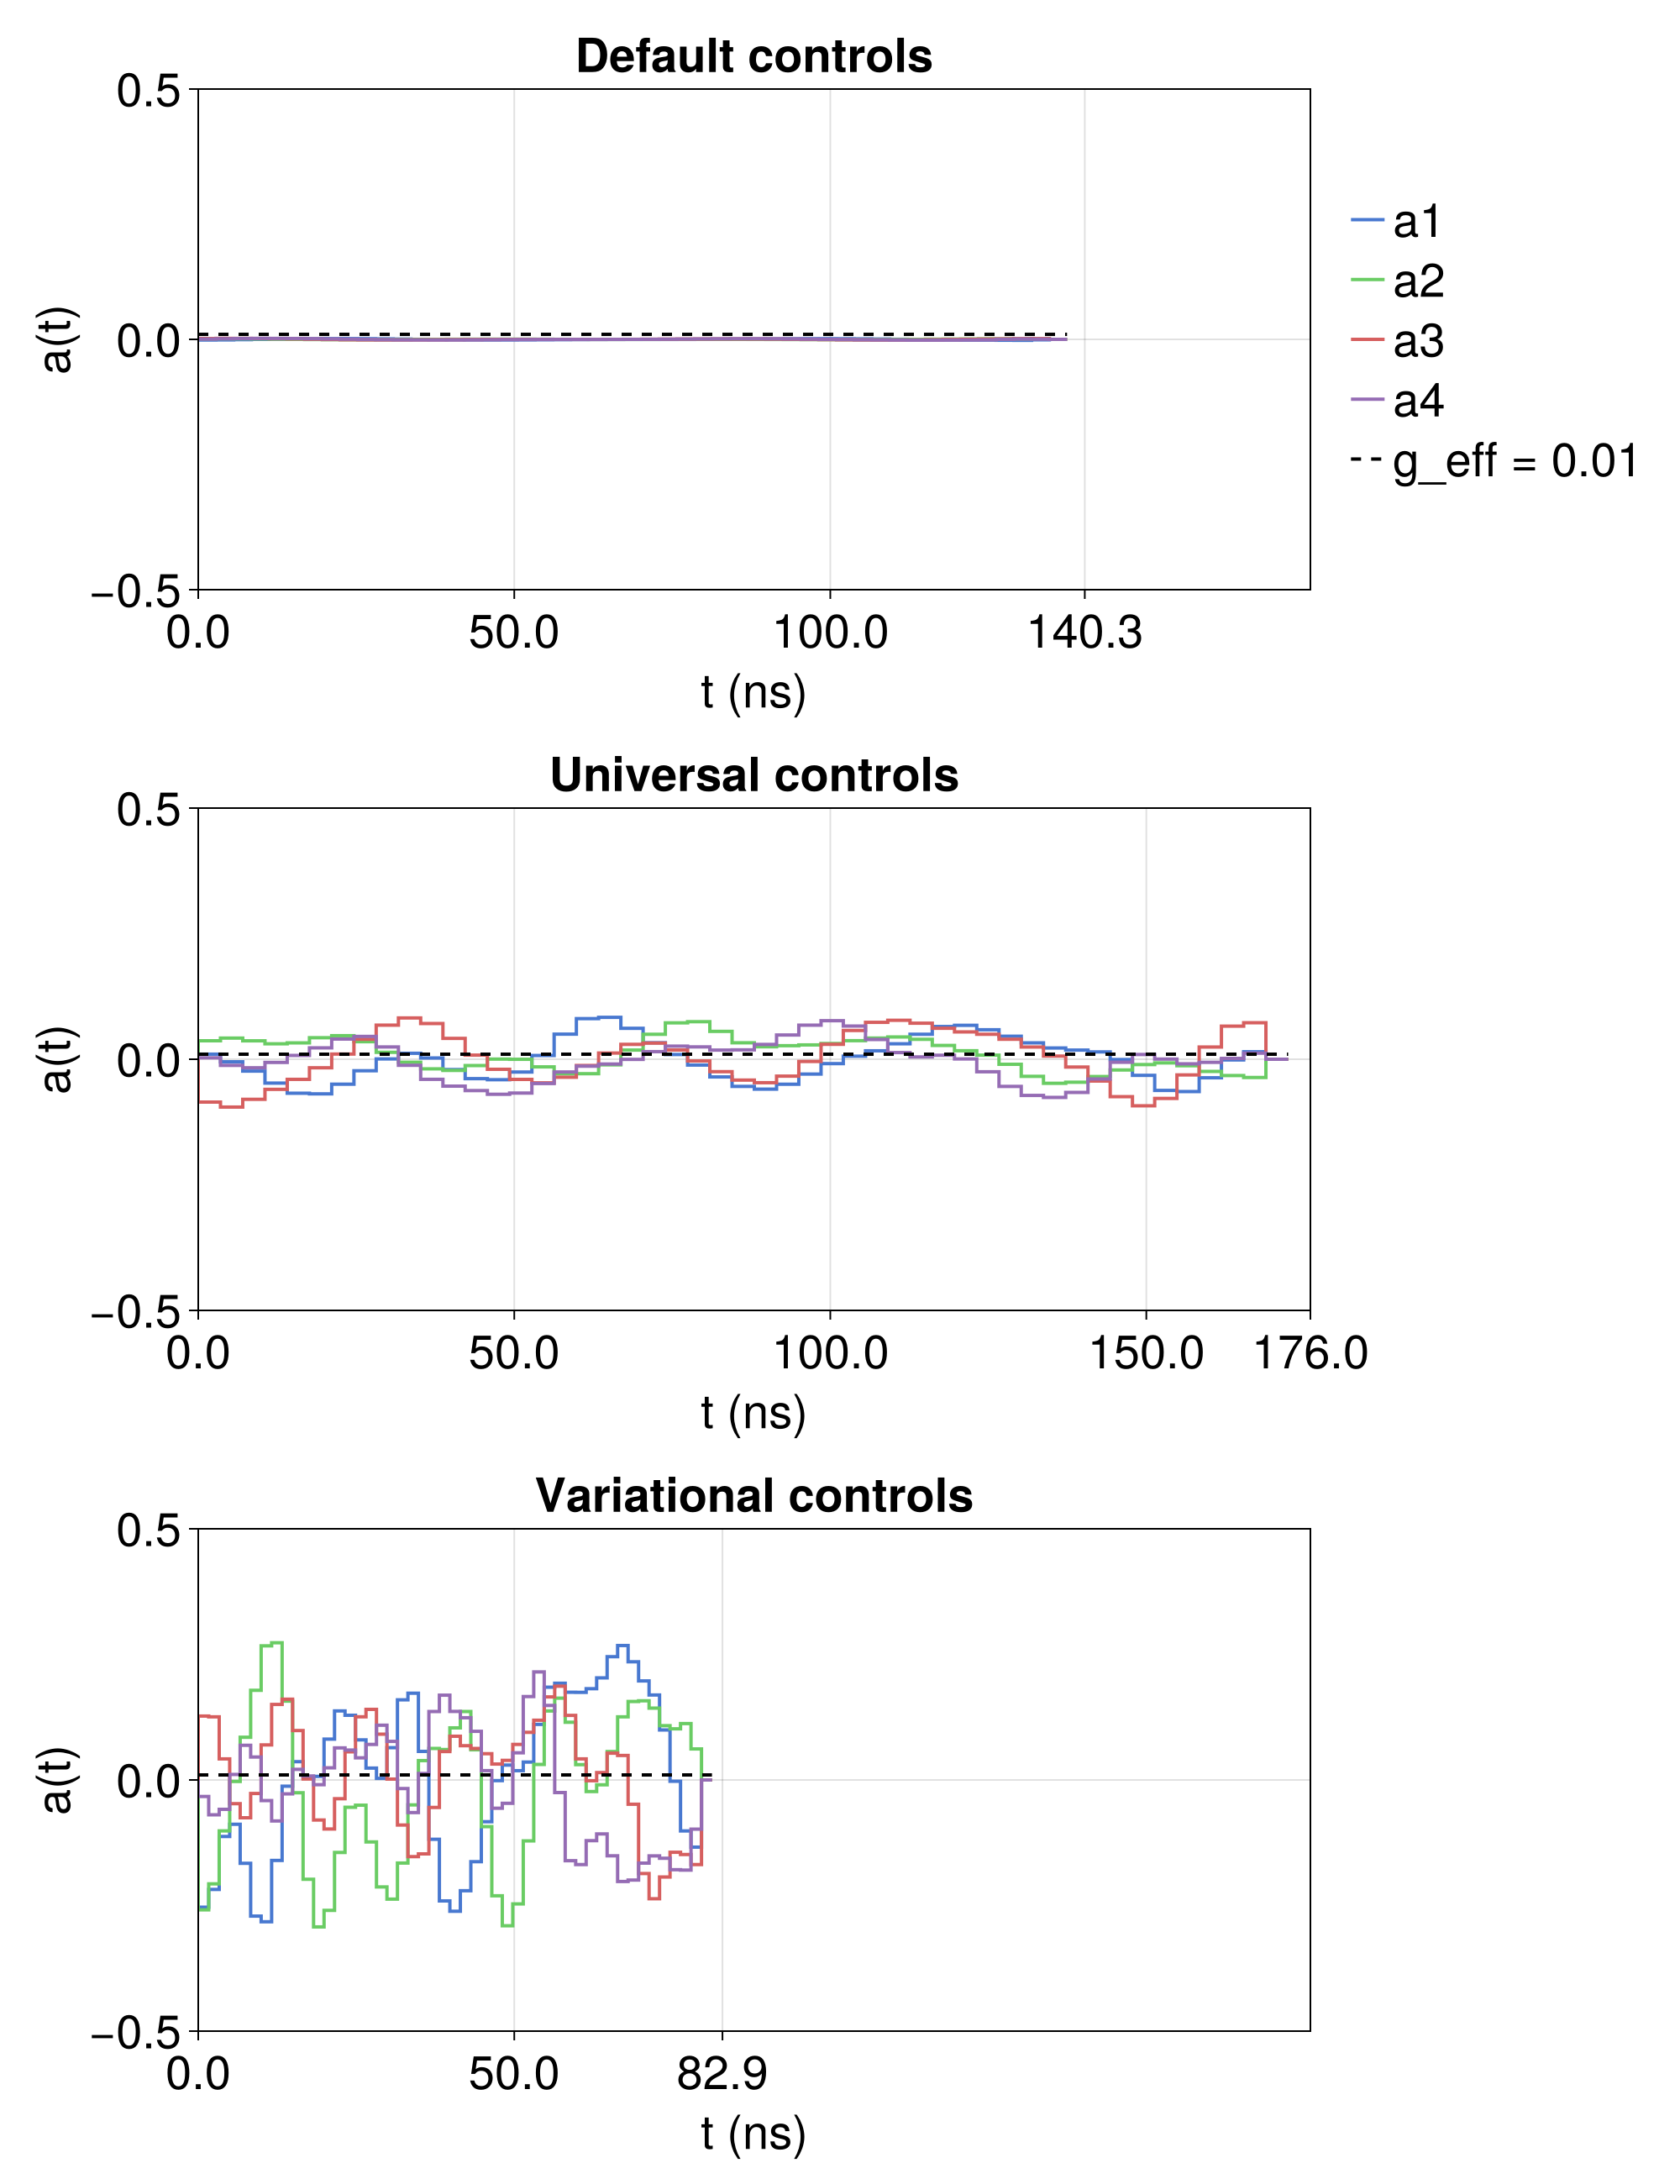

CairoMakie.Screen{IMAGE}


In [9]:
# %% ONE FIGURE: 3 stacked subplots (Default / Universal / Variational)
#    Plot :a as true PWC on t_nodes (no artificial padding/shift)
#    seaborn muted colors + xticks every 50 ns
#    dashed g_eff starts at t=0 and ends at the end of the last "microwaves on" interval
#
#    Font sizes matched to your fidelity-curve plot:
#      Figure(fontsize=28, size=(1000, 1000))  (scaled taller for 3 rows)
#      Axis titles/labels default to fig fontsize unless overridden

using CairoMakie
using ColorSchemes

problems = [
    (def,      "Default"),
    (uni_prob, "Universal"),
    (var_prob, "Variational"),
]

# seaborn muted palette (first 4)
cols = ColorSchemes.seaborn_muted6.colors
a_colors = (cols[1], cols[2], cols[3], cols[4])

# --- robust get ---
traj_get(traj, sym::Symbol) = try traj[sym] catch; getproperty(traj, sym) end

# --- Δt as 1D vector (ns) ---
dt_vector(traj) = vec(collect(traj_get(traj, :Δt)))

# --- ensure :a is (Ntime, Nctrl) ---
function a_matrix(traj)
    Araw = traj_get(traj, :a)
    A = ndims(Araw) == 1 ? reshape(collect(Araw), :, 1) : Matrix(Araw)
    if size(A, 1) ≤ 10 && size(A, 2) > size(A, 1)
        A = A'
    end
    return A
end

# --- node times from Δt (ns) ---
time_nodes_ns(traj) = cumsum(vcat(0.0, Float64.(dt_vector(traj))))  # length Ndt+1

function as_interval_values(u::AbstractVector{<:Real}, Ndt::Int)
    u = Float64.(u)
    if length(u) == Ndt
        return u
    elseif length(u) == Ndt + 1
        return u[1:end-1]
    else
        error("Control length $(length(u)) incompatible with Ndt=$Ndt")
    end
end

intervals_to_stairs_y(v::AbstractVector{<:Real}) = vcat(Float64.(v), NaN)

function plot_panel!(ax, traj;
    title_str::String,
    ylims_tuple=(-0.5, 0.5),
    xtick_step=50.0,
    g_eff=0.01,
    on_tol=1e-6,
    show_legend_labels::Bool=true
)
    A = a_matrix(traj)
    _, nctrl = size(A)
    @assert nctrl ≥ 4 "Expected at least 4 controls in :a, got $nctrl"

    dt_ns = Float64.(dt_vector(traj))
    Ndt = length(dt_ns)
    t_nodes = time_nodes_ns(traj)
    @assert length(t_nodes) == Ndt + 1

    ax.title  = title_str
    ax.xlabel = "t (ns)"
    ax.ylabel = "a(t)"

    # Build interval values for a1..a4, plot as PWC stairs
    v_list = Vector{Vector{Float64}}(undef, 4)
    for j in 1:4
        v = as_interval_values(A[:, j], Ndt)
        v_list[j] = v
        y = intervals_to_stairs_y(v)
        stairs!(ax, t_nodes, y; linewidth=2, color=a_colors[j],
                label = show_legend_labels ? "a$j" : "")
    end

    # Determine microwave-on intervals from the plotted PWC values
    active = falses(Ndt)
    for i in 1:Ndt
        active[i] = maximum(abs.((v_list[1][i], v_list[2][i], v_list[3][i], v_list[4][i]))) > on_tol
    end

    # dashed g_eff: start at t=0, end at end of last active interval
    if any(active)
        i2 = findlast(active)
        t_end = t_nodes[i2 + 1]
        lines!(ax, [0.0, t_end], [g_eff, g_eff];
            linestyle=:dash, linewidth=2, color=:black,
            label = show_legend_labels ? "g_eff = $(g_eff)" : ""
        )
    end

    ylims!(ax, ylims_tuple...)

    # xticks every 50 ns; include endpoint tick
    xmax = t_nodes[end]
    ticks = collect(0.0:xtick_step:(floor(xmax/xtick_step)*xtick_step))
    isempty(ticks) && (ticks = [0.0])
    if abs(ticks[end] - xmax) > 1e-9
        ticks = vcat(ticks, xmax)
    end
    ax.xticks = (ticks, string.(round.(ticks, digits=1)))

    return xmax
end

# Match your other figure: fontsize=28.
# Keep width 1000; height scaled to 3 rows (≈1000 * 3 / 1) but a bit tighter.
fig = Figure(fontsize=28, size=(1000, 1300))

axes = [
    Axis(fig[1, 1]),
    Axis(fig[2, 1]),
    Axis(fig[3, 1]),
]

Tpulses = Float64[]
for (k, ((prob, label), ax)) in enumerate(zip(problems, axes))
    Tpulse = plot_panel!(ax, prob.trajectory;
        title_str = "$label controls",
        ylims_tuple = (-0.5, 0.5),
        xtick_step = 50.0,
        g_eff = 0.01,
        on_tol = 1e-6,
        show_legend_labels = (k == 1),
    )
    push!(Tpulses, Tpulse)
end

# unify x-limits across panels
Tmax = maximum(Tpulses)
for ax in axes
    xlims!(ax, 0, Tmax)
end

Legend(fig[1, 2], axes[1]; framevisible=false)

display(fig)

In [10]:

mkpath("figures")  # creates "figures/" if it doesn't exist

save(joinpath("figures", "controls_pwc.png"), fig; px_per_unit = 5)  # PNG

In [11]:
def.trajectory.a[1,:]

50-element Vector{Float64}:
  0.0
 -0.0013063426655485575
 -0.001071420174488058
 -0.0005521299568469276
 -1.2570957669998245e-5
  0.0004858567911177974
  0.0009399148782407713
  0.0012950004235606977
  0.001503190644022295
  0.0015207450992204754
  ⋮
 -0.00030979914553056447
 -0.0008047448563985764
 -0.001243543265257962
 -0.0014403868535390607
 -0.0014631650078949785
 -0.0017684363339299006
 -0.0019403406585469566
 -0.0009049959728663293
  0.0

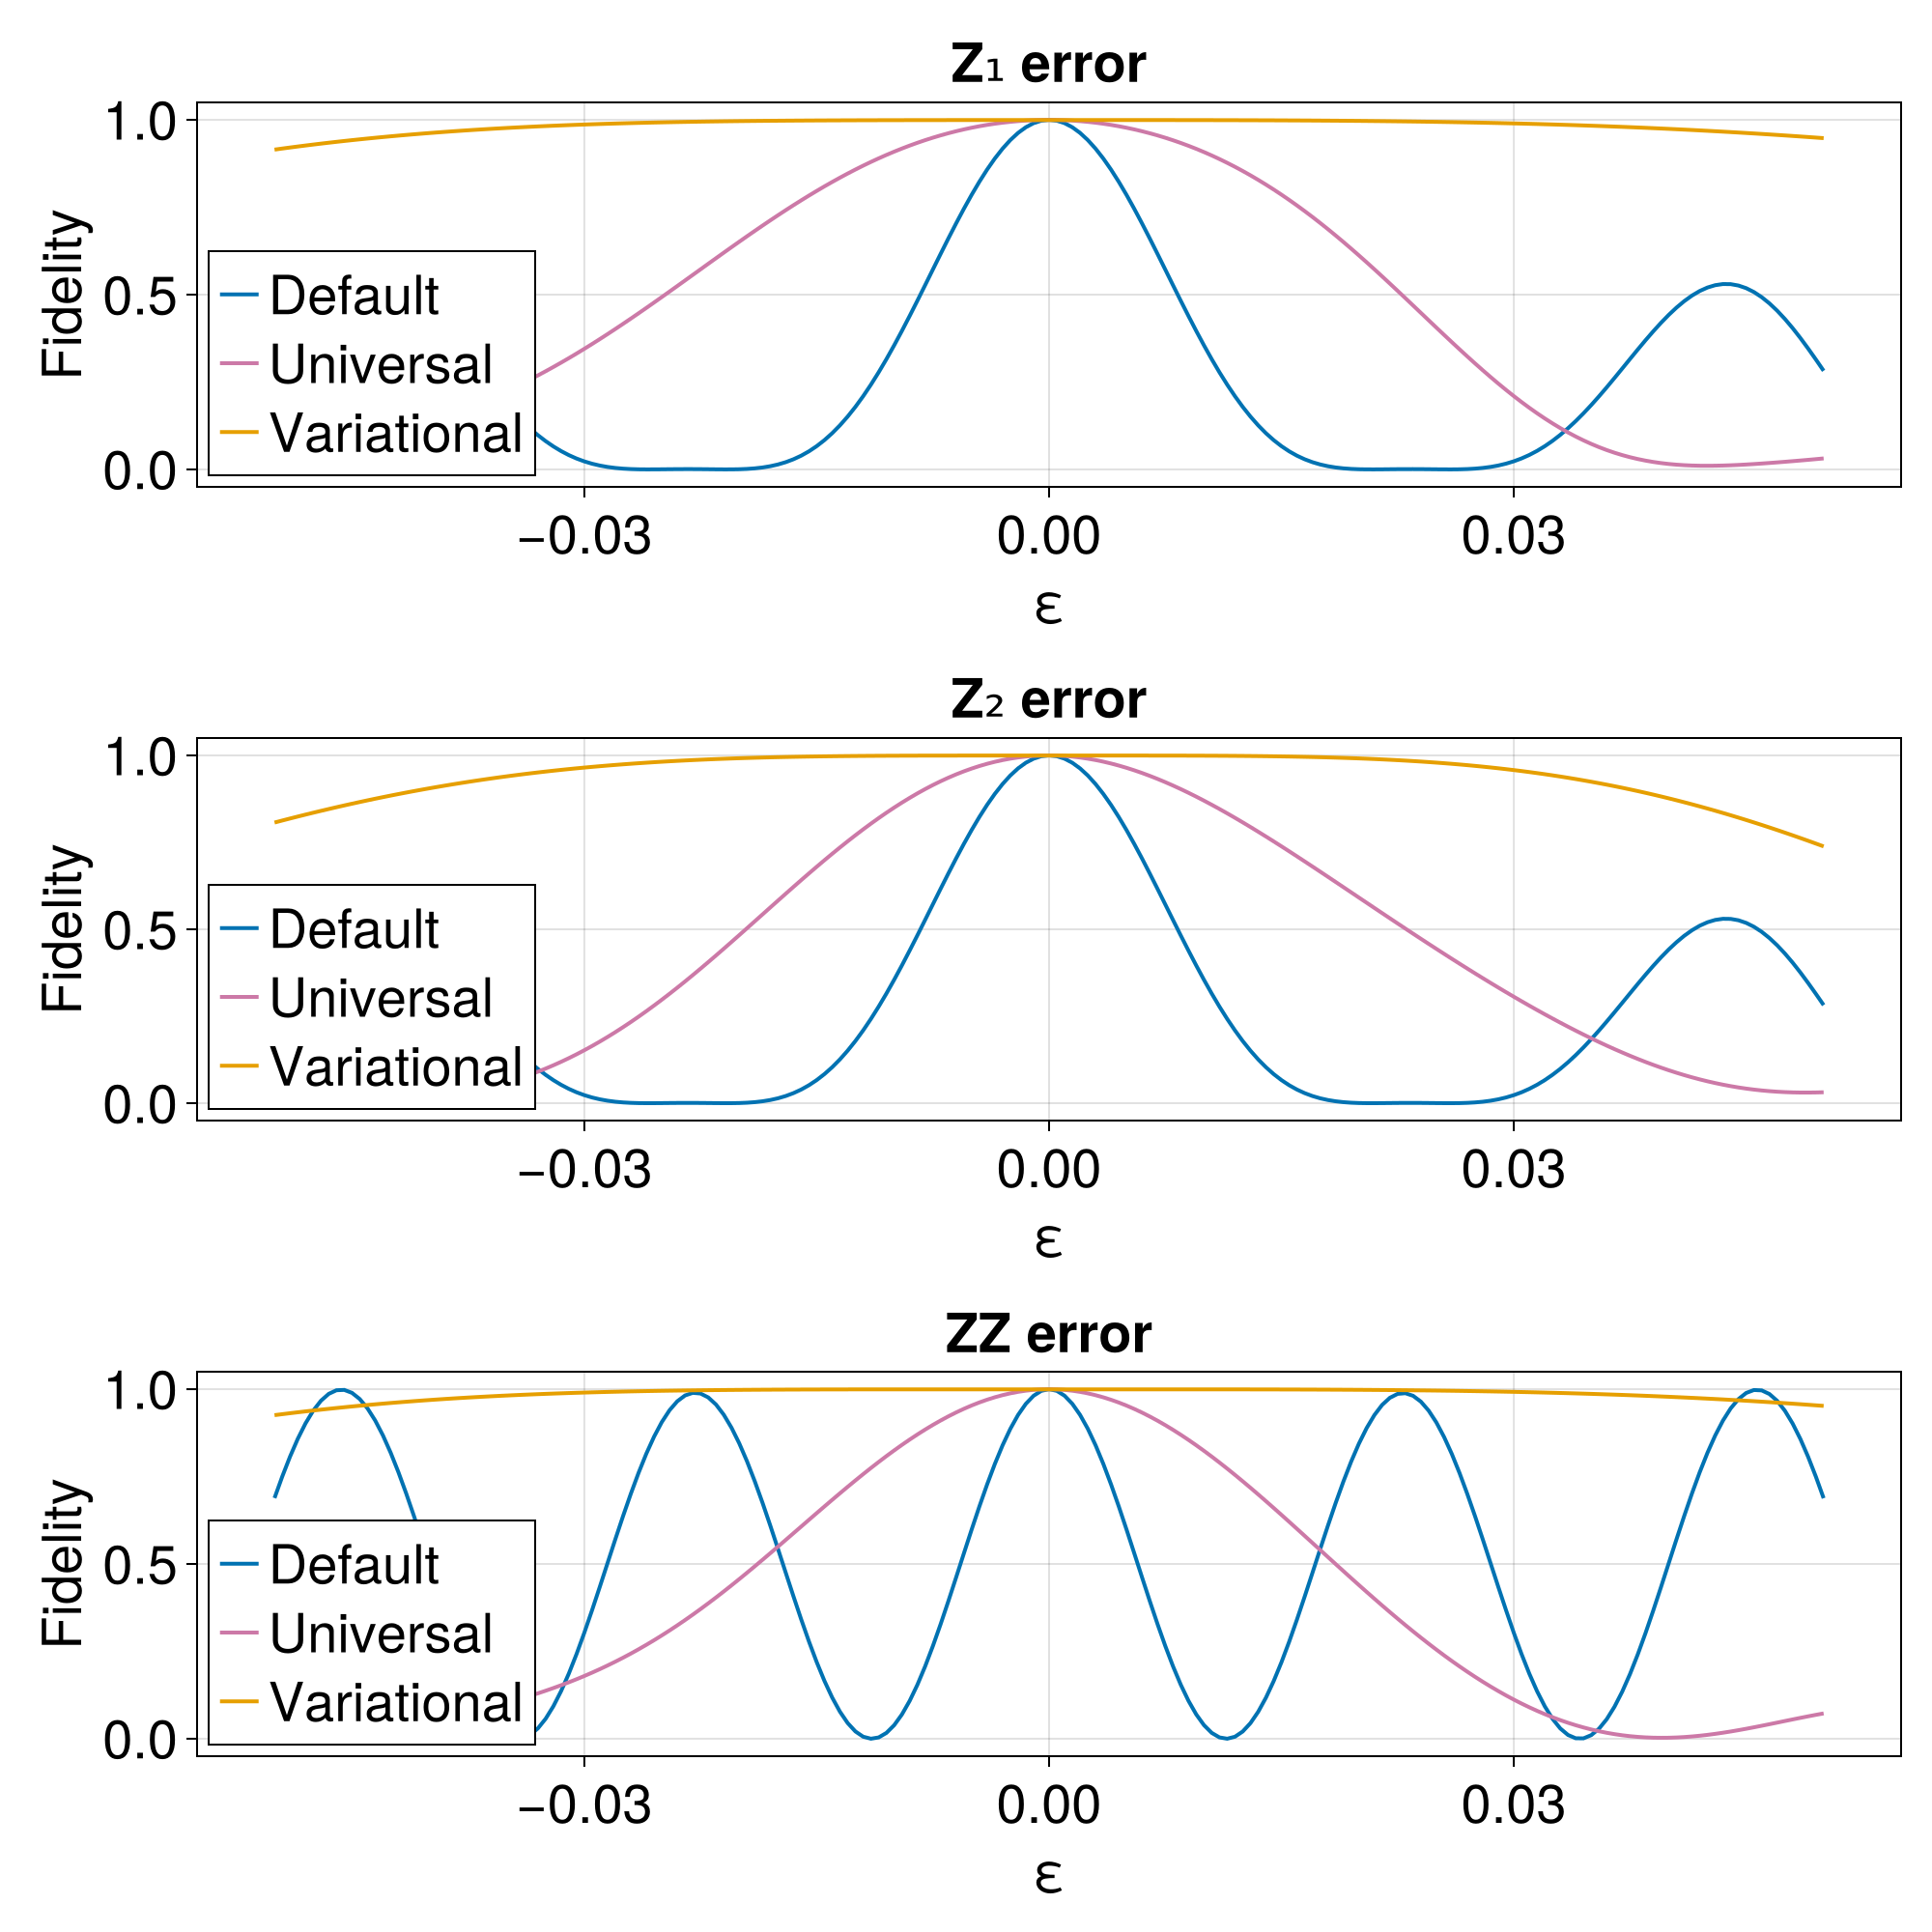

CairoMakie.Screen{IMAGE}


In [12]:

# %% Cell 2 — fidelity curves vs Z1, Z2, ZZ error strength (CORRECT drift addition)

using CairoMakie
⊗ = kron

# --- Build error operators using SAME basis as optimization (GATES.*) ---
Z1_err = GATES.Z ⊗ GATES.I
Z2_err = GATES.I ⊗ GATES.Z
ZZ_err = GATES.Z ⊗ GATES.Z

errors = [
    (Z1_err, "Z₁"),
    (Z2_err, "Z₂"),
    (ZZ_err, "ZZ"),
]

# --- Use the SAME control Hamiltonians and drift as optimization ---
# assumes these exist from your solve cell:
#   H_drive :: Vector{Matrix{ComplexF64}}
#   H_drift :: Matrix{ComplexF64}

problems = [
    (def,      "Default"),
    (uni_prob, "Universal"),
    (var_prob, "Variational"),
]

εs = collect(-0.05:0.0005:0.05)

# Sweep: drift + ε*error, with the same controls
fidelity_curve(prob, H_err) = [
    unitary_rollout_fidelity(prob.trajectory, QuantumSystem(H_drift + ε * H_err, H_drive))
    for ε in εs
]

colors = Makie.wong_colors()
colors = [colors[1], colors[4], colors[2]]
f = Figure(fontsize=28, size=(1000, 1000))

for (row, (H_err, label_err)) in enumerate(errors)
    ax = Axis(f[row, 1],
        title  = "$label_err error",
        xlabel = "ε",
        ylabel = "Fidelity",
    )

    for (i, (prob, label_prob)) in enumerate(problems)
        ys = fidelity_curve(prob, H_err)
        lines!(ax, εs, ys; label=label_prob, color=colors[i], linewidth=2)
    end

    axislegend(ax; position=:lb)
end

display(f)



In [ ]:

mkpath("figures")  # creates "figures/" if it doesn't exist

save(joinpath("figures", "fidelities.png"), f; px_per_unit = 5)  # PNG